# 037 正则化与数据增强
先核对完整计算，再看有限消融。请重启内核后顺序运行全部。这里不会把新的运行覆盖为旧参考答案，也不从测试结果改配置。详细推导见lecture，协议见lab。

In [1]:
# 首格只用标准库：先验证完整输入，后导入实验模块。
from pathlib import Path
import os, sys, hashlib, json, csv, io, tempfile
EXPECTED = {'experiment.py': 'dab2197a231af0f35d8e9241301b7f2d9f5d30d71144c3bdbf8695d2c481e1e4', 'test_experiment.py': '21e0f5d2c8e7d4e3bedbe076f2253122107f111df5714d9b32d913904149d017', 'make_figures.py': '6f42d566f7bc8d8533c55249ab2b57c978a1df1a7da65b721e9ec0bf320e5cec', 'data/train.csv': '6f5c7acc5d166b12381c70d17856f61c36b7652bc447ae88fc51b8cbe8a4b345', 'data/validation.csv': 'e39035f479d309e67352365edb4505369846a74533fd7aa6ab0e1a5d94c928d5', 'data/test.csv': 'e78dc1e856bccce001fe041e7660a0488a3547c0a345e58069719ab49269b51e', 'outputs/ablation.csv': '865d113108e413e1dae3403833434a030ade7294a43ccde7d984972dc99cf190', 'outputs/calculations.json': 'd386873d1be294a5a348d9a8106fcf044bac4a4133ac8ea4bd015d6112045d67', 'outputs/decision-grid.json': '688f807278eafd452f2484d9ea6aeddda70769daa843d12ab01b8130461fc4f5', 'outputs/run-details.json': '987d5681fb9359f80d8fd6b3e13f1de4780fd567465c25bfdda8eae3806547be', 'outputs/test-predictions.csv': '4629468540912f4bb9f78ecd71cf012ebe476b00b9c8b0213e591c647166675d', 'outputs/training-history.csv': 'be857fb73bbe4bae26d23d00d66afe0b6f067d2171e8545c2b5a38516e3588a6'}
if os.environ.get('UNIT037_DIR'):
    UNIT = Path(os.environ['UNIT037_DIR']).expanduser().resolve()
else:
    candidates = [Path.cwd().resolve(), (Path.cwd()/'units'/'037').resolve()]
    valid = [p for p in candidates if (p/'experiment.py').is_file() and (p/'data'/'train.csv').is_file()]
    if len(valid) != 1:
        raise RuntimeError('从037目录或课程仓库根启动，或设置UNIT037_DIR；拒绝猜测其他同名目录')
    UNIT = valid[0]
for relative, expected in EXPECTED.items():
    file = UNIT/relative
    if not file.is_file() or hashlib.sha256(file.read_bytes()).hexdigest() != expected:
        raise ValueError('输入版本或完整性不符：'+relative)
sys.path.insert(0,str(UNIT))
# Avoid a prior different module named experiment surviving a notebook rerun.
for module_name in ('experiment','make_figures'):
    if module_name in sys.modules:
        del sys.modules[module_name]
print('已校验', len(EXPECTED), '份代码、数据与参考结果；尚未运行训练。')

已校验 12 份代码、数据与参考结果；尚未运行训练。


## 数据与随机对象
数据固定不变；三个算法种子共同改变初始化、顺序、dropout和增强，各过程采用独立流。clean_y仅审计，不参与拟合。

In [2]:
import numpy as np, torch
import experiment as e
torch.set_num_threads(1)
data = e.read_data()
print('torch',torch.__version__,'numpy',np.__version__)
for name,d in data.items():
    print(name, 'n=',len(d['y']), 'positive=',int(d['y'].sum()), 'flipped=',int(np.sum(d['y']!=d['clean_y'])))
print('处理:',e.CONFIGS,'算法种子:',e.SEEDS)

torch 2.7.1+cpu numpy 2.3.5
train n= 48 positive= 21 flipped= 9
validation n= 96 positive= 40 flipped= 12
test n= 384 positive= 191 flipped= 59
处理: ('baseline', 'early_stop', 'dropout', 'decay', 'augment_valid', 'augment_invalid', 'label_smooth') 算法种子: (370, 371, 372)


## 固定掩码的逐样本前向
先手算，再运行。两个1/2分别来自半平方和样本平均；W与u受惩罚，偏置不受惩罚。

In [3]:
trace = e.hand_trace()
first = trace['initial']
for i in range(2):
    print('sample',i+1,'Z',first['z'][i],'H',first['h'][i], 'mask',first['mask'][i], 'H_dropout',first['h_dropout'][i],
          'P',first['prediction'][i],'residual',first['residual'][i],'half-square',first['per_sample_half_square'][i])
print('L, penalty, J:',first['data_loss'],first['penalty'],first['objective'])
for key in ('d_prediction','d_h_dropout','d_h','relu_gate','d_z','input_gradient'):
    print(key,first[key])

sample 1 Z [1.2000000000000002, 0.8] H [1.2000000000000002, 0.8] mask [1.0, 0.0] H_dropout [2.4000000000000004, 0.0] P 1.5400000000000003 residual 0.8400000000000003 half-square 0.3528000000000003
sample 2 Z [-0.1, 0.8] H [0.0, 0.8] mask [1.0, 1.0] H_dropout [0.0, 1.6] P -0.7000000000000001 residual -0.5 half-square 0.125
L, penalty, J: 0.23890000000000014 0.057499999999999996 0.2964000000000001
d_prediction [0.42000000000000015, -0.25]
d_h_dropout [[0.25200000000000006, -0.21000000000000008], [-0.15, 0.125]]
d_h [[0.5040000000000001, -0.0], [-0.3, 0.25]]
relu_gate [[1.0, 1.0], [0.0, 1.0]]
d_z [[0.5040000000000001, -0.0], [-0.0, 0.25]]
input_gradient [[0.25200000000000006, 0.15120000000000003], [-0.05, 0.1]]


## 全部共享参数的路径和同时更新
每行保留两个样本来源以及惩罚路径。必须先收齐旧参数处的所有梯度，再一起更新。

In [4]:
print('name sample1 sample2 penalty gradient old updated')
for j,name in enumerate(trace['parameter_order']):
    values=[first['sample_parameter_paths'][0][j],first['sample_parameter_paths'][1][j],first['penalty_gradient'][j],first['gradient'][j],first['theta'][j],trace['updated_theta'][j]]
    print(name,*[f'{x:.9f}' for x in values])
for key in ('same_mask_next','fresh_mask_next','eval_next'):
    row=trace[key]
    print(key,'Z',row['z'],'P',row['prediction'],'data',row['data_loss'],'penalty',row['penalty'],'J',row['objective'])
print('下一轮同mask梯度:',trace['same_mask_next']['gradient'])

name sample1 sample2 penalty gradient old updated
W11 0.504000000 0.000000000 0.050000000 0.554000000 0.500000000 0.472300000
W12 -0.000000000 -0.250000000 -0.020000000 -0.270000000 -0.200000000 -0.186500000
W21 1.008000000 -0.000000000 0.030000000 1.038000000 0.300000000 0.248100000
W22 -0.000000000 0.250000000 0.040000000 0.290000000 0.400000000 0.385500000
b1 0.504000000 -0.000000000 0.000000000 0.504000000 0.100000000 0.074800000
b2 -0.000000000 0.250000000 0.000000000 0.250000000 0.200000000 0.187500000
u1 1.008000000 -0.000000000 0.060000000 1.068000000 0.600000000 0.546600000
u2 0.000000000 -0.400000000 -0.050000000 -0.450000000 -0.500000000 -0.477500000
c 0.420000000 -0.250000000 0.000000000 0.170000000 0.100000000 0.091500000
same_mask_next Z [[1.0433, 0.772], [-0.1494, 0.7595000000000001]] P [1.2320355599999997, -0.6338225] data 0.11781594965269082 penalty 0.0497395605 J 0.16755551015269082
fresh_mask_next Z [[1.0433, 0.772], [-0.1494, 0.7595000000000001]] P [0.49477555999999

## 十六张掩码精确枚举
固定参数后枚举所有可能，不把抽样误差混进期望公式。末端额外sigmoid只展示非线性，并不是训练好的分类网络。

In [5]:
enum=e.enumerate_masks()
for row in enum['rows']:
    print('mask',row['mask'],'P',np.round(row['prediction'],6),'data_loss',round(row['data_loss'],6))
print('E[P]',enum['mean_prediction'],'no dropout P',enum['no_dropout']['prediction'])
print('E[half-square]',enum['mean_data_loss'],'no dropout',enum['no_dropout']['data_loss'],'variance extra',enum['variance_term'])
print('sigmoid(E[P])',1/(1+np.exp(-np.array(enum['mean_prediction']))))
print('E[sigmoid(P)]',enum['mean_sigmoid_prediction'])

mask [0.0, 0.0, 0.0, 0.0] P [0.1 0.1] data_loss 0.1125
mask [0.0, 0.0, 0.0, 1.0] P [ 0.1 -0.7] data_loss 0.1525
mask [0.0, 0.0, 1.0, 0.0] P [0.1 0.1] data_loss 0.1125
mask [0.0, 0.0, 1.0, 1.0] P [ 0.1 -0.7] data_loss 0.1525
mask [0.0, 1.0, 0.0, 0.0] P [-0.7  0.1] data_loss 0.5125
mask [0.0, 1.0, 0.0, 1.0] P [-0.7 -0.7] data_loss 0.5525
mask [0.0, 1.0, 1.0, 0.0] P [-0.7  0.1] data_loss 0.5125
mask [0.0, 1.0, 1.0, 1.0] P [-0.7 -0.7] data_loss 0.5525
mask [1.0, 0.0, 0.0, 0.0] P [1.54 0.1 ] data_loss 0.1989
mask [1.0, 0.0, 0.0, 1.0] P [ 1.54 -0.7 ] data_loss 0.2389
mask [1.0, 0.0, 1.0, 0.0] P [1.54 0.1 ] data_loss 0.1989
mask [1.0, 0.0, 1.0, 1.0] P [ 1.54 -0.7 ] data_loss 0.2389
mask [1.0, 1.0, 0.0, 0.0] P [0.74 0.1 ] data_loss 0.0229
mask [1.0, 1.0, 0.0, 1.0] P [ 0.74 -0.7 ] data_loss 0.0629
mask [1.0, 1.0, 1.0, 0.0] P [0.74 0.1 ] data_loss 0.0229
mask [1.0, 1.0, 1.0, 1.0] P [ 0.74 -0.7 ] data_loss 0.0629
E[P] [0.4200000000000001, -0.30000000000000004] no dropout P [0.42000000000000004, -

## 模式和标签平滑
Dropout没有BN运行统计；no_grad不关闭训练态采样。eval恒等返回原输入时requires_grad可保留，这是边界检查而非异常。

In [6]:
probe=e.mode_probe()
for row in probe['dropout_modes']:
    print('training=',row['training'],'grad_enabled=',row['grad_enabled'],'requires_grad=',row['requires_grad'])
    print('first',row['first'],'second',row['second'],'input_gradient',row['input_gradient'])
print(probe['label_smoothing_framework'])

training= True grad_enabled= True requires_grad= True
first [[2.0, 2.0, 0.0, 0.0, 2.0, 2.0], [2.0, 2.0, 0.0, 2.0, 2.0, 2.0]] second [[0.0, 2.0, 0.0, 2.0, 0.0, 2.0], [2.0, 0.0, 0.0, 2.0, 2.0, 0.0]] input_gradient [[2.0, 2.0, 0.0, 0.0, 2.0, 2.0], [2.0, 2.0, 0.0, 2.0, 2.0, 2.0]]
training= True grad_enabled= False requires_grad= False
first [[2.0, 2.0, 0.0, 0.0, 2.0, 2.0], [2.0, 2.0, 0.0, 2.0, 2.0, 2.0]] second [[0.0, 2.0, 0.0, 2.0, 0.0, 2.0], [2.0, 0.0, 0.0, 2.0, 2.0, 0.0]] input_gradient None
training= False grad_enabled= True requires_grad= True
first [[1.0, 1.0, 1.0, 1.0, 1.0, 1.0], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0]] second [[1.0, 1.0, 1.0, 1.0, 1.0, 1.0], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0]] input_gradient [[1.0, 1.0, 1.0, 1.0, 1.0, 1.0], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0]]
training= False grad_enabled= False requires_grad= True
first [[1.0, 1.0, 1.0, 1.0, 1.0, 1.0], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0]] second [[1.0, 1.0, 1.0, 1.0, 1.0, 1.0], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0]] input_gradient None
{'torch

## 完整重跑并核对六份结果
新运行只写临时目录。完成七处理×三种子之后统一评估测试。通过的是当前环境重现性，不是普适性能保证。

In [7]:
with tempfile.TemporaryDirectory(prefix='unit037-replay-') as work:
    report=e.run(Path(work))
    for name,digest in report['hashes'].items():
        expected=EXPECTED['outputs/'+name]
        if digest != expected:
            raise RuntimeError('重跑不一致：'+name+'；先检查版本与协议，不要覆盖参考结果')
    reproduced_details=json.loads((Path(work)/'run-details.json').read_text())
    reproduced_rows=list(csv.DictReader(io.StringIO((Path(work)/'ablation.csv').read_text())))
print('六份结果摘要完全一致；临时目录已清理。')
print({k:report[k] for k in ('runs','updates','history_rows','test_prediction_rows')})

六份结果摘要完全一致；临时目录已清理。
{'runs': 21, 'updates': 8898, 'history_rows': 2987, 'test_prediction_rows': 8064}


## 保留全部21行 不挑种子
每列CE均使用原始硬标签。测试错误率与Brier会给不同维度的信息。

In [8]:
print('config seed stop selected updates trainCE validationCE testCE error Brier')
for row in reproduced_rows:
    print(row['config'],row['seed'],row['epochs_run'],row['selected_epoch'],row['updates'],
          *[f"{float(row[k]):.8f}" for k in ('train_ce','validation_ce','test_ce','test_error','test_brier')])

config seed stop selected updates trainCE validationCE testCE error Brier
baseline 370 160 160 480 0.44291704 0.43183066 0.50033094 0.17968750 0.14987093
baseline 371 160 160 480 0.43546384 0.44017472 0.52117519 0.18489583 0.15428797
baseline 372 160 160 480 0.47041007 0.44075209 0.47423537 0.17447917 0.14447765
early_stop 370 37 17 111 0.48498593 0.41852634 0.45739322 0.15885417 0.14066878
early_stop 371 24 4 72 0.48985410 0.41641071 0.46336173 0.17708333 0.14267943
early_stop 372 25 5 75 0.50090101 0.41271945 0.46653619 0.19010417 0.14428187
dropout 370 160 160 480 0.46332332 0.42507988 0.47762250 0.16927083 0.14545077
dropout 371 160 160 480 0.46119126 0.42229168 0.48362119 0.17447917 0.14593440
dropout 372 160 160 480 0.47583776 0.42652233 0.45531611 0.16666667 0.14026873
decay 370 160 160 480 0.46723740 0.44149921 0.47899770 0.17968750 0.14638833
decay 371 160 160 480 0.46336465 0.44158565 0.48797707 0.18229167 0.14802636
decay 372 160 160 480 0.48272731 0.42358851 0.45805757 0.15

## 检查增强语义和指标反例
合法性只对当前已知合成任务成立；重复呈现不增加独立原样本数。

In [9]:
for row in reproduced_rows:
    if row['config'].startswith('augment_'):
        print(row['config'],row['seed'],'selected',row['selected_augmentation_count'],'semantic_change',row['semantic_change_count'])
for seed in e.SEEDS:
    a=next(r for r in reproduced_rows if r['config']=='baseline' and int(r['seed'])==seed)
    b=next(r for r in reproduced_rows if r['config']=='label_smooth' and int(r['seed'])==seed)
    c=next(r for r in reproduced_rows if r['config']=='early_stop' and int(r['seed'])==seed)
    print('seed',seed,'平滑ΔBrier',float(b['test_brier'])-float(a['test_brier']),
          '早停Δ错误率',float(c['test_error'])-float(a['test_error']))

augment_valid 370 selected 3865 semantic_change 0
augment_valid 371 selected 3806 semantic_change 0
augment_valid 372 selected 3781 semantic_change 0
augment_invalid 370 selected 3865 semantic_change 3865
augment_invalid 371 selected 3806 semantic_change 3806
augment_invalid 372 selected 3781 semantic_change 3781
seed 370 平滑ΔBrier 0.0008257839900090436 早停Δ错误率 -0.020833333333333343
seed 371 平滑ΔBrier -0.00028561748032945866 早停Δ错误率 -0.0078125
seed 372 平滑ΔBrier -0.0005459440102765778 早停Δ错误率 0.015625


## 从核验过的源重新绘图
图脚本先检查所有数值文件与原数据，再写临时图目录。这里显示期望边界、早停、全消融和校准边界四幅；讲义提供全部13幅。

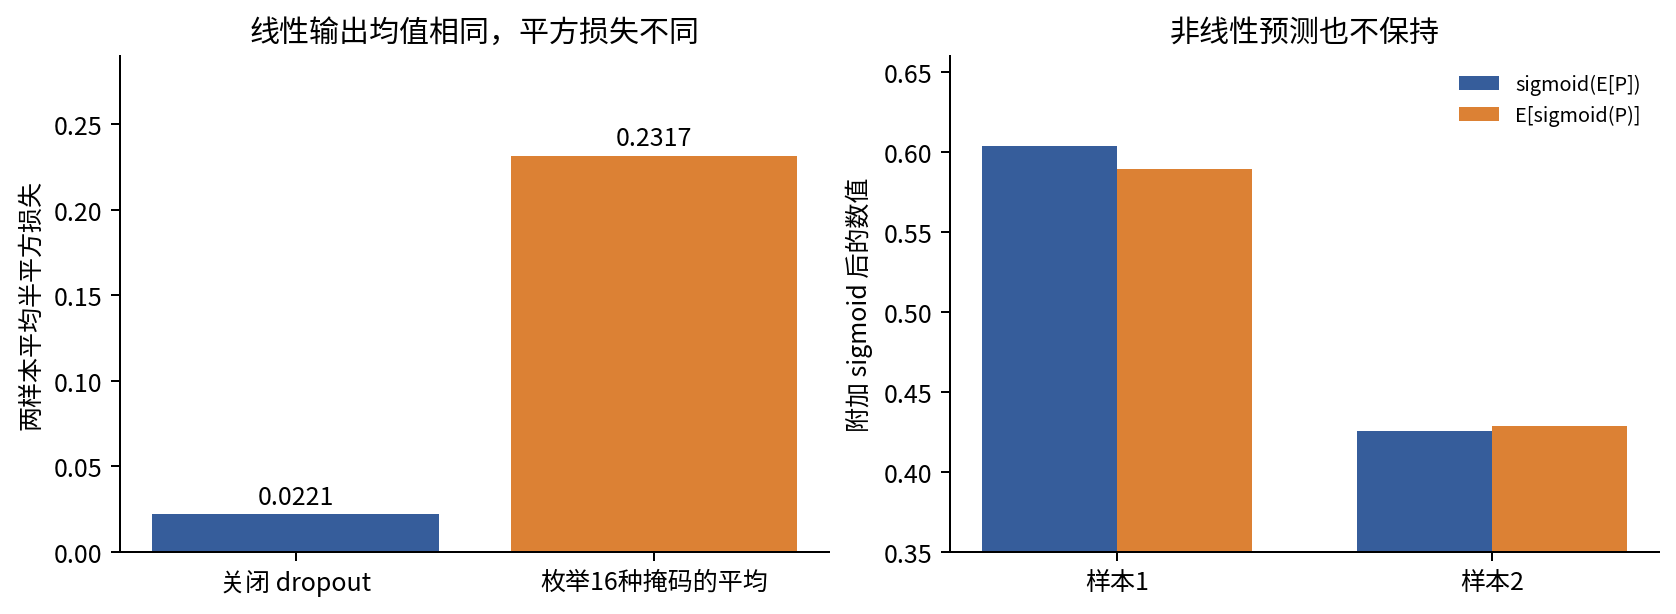

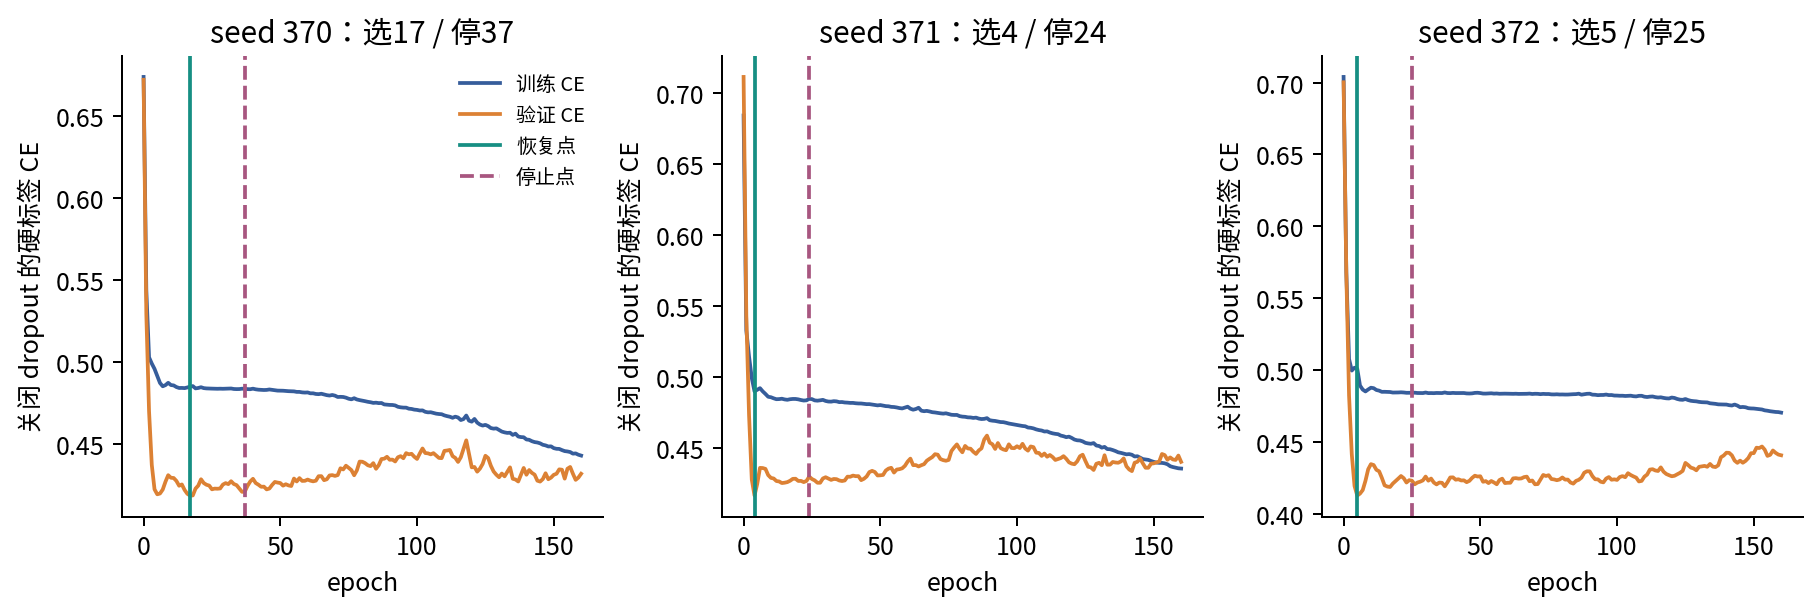

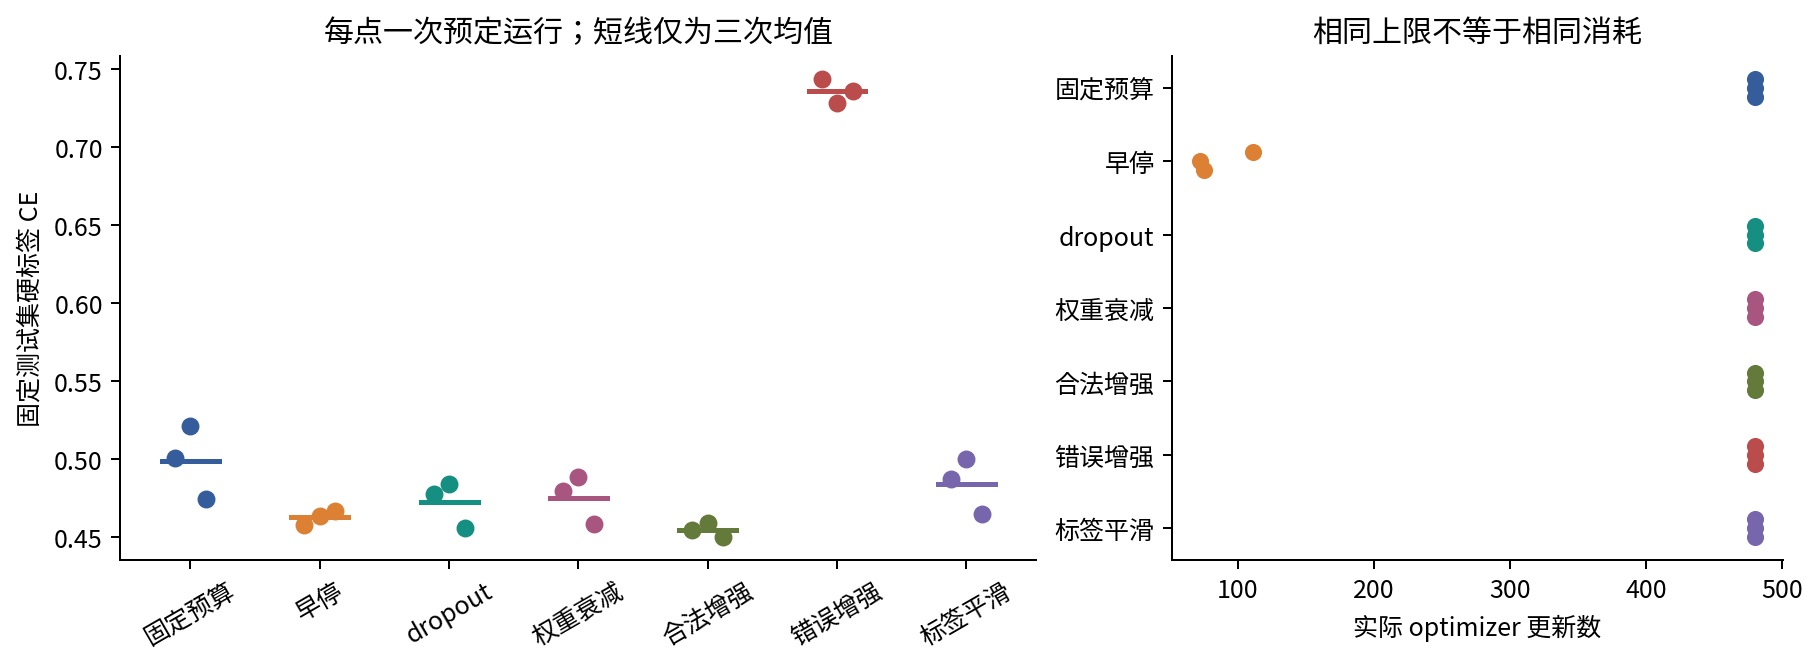

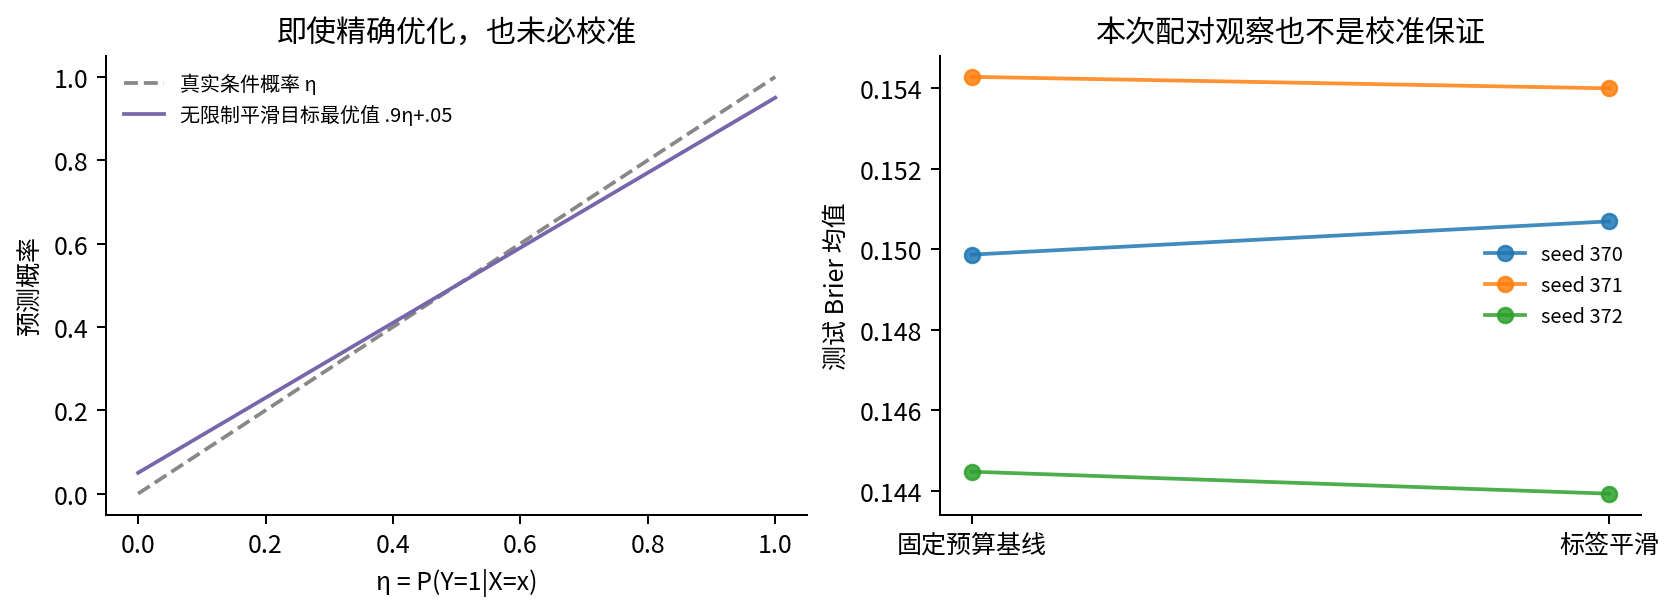

{'figures': 13, 'source_files': 6}


In [10]:
import make_figures
from IPython.display import display,Image
with tempfile.TemporaryDirectory(prefix='unit037-figures-') as figwork:
    info=make_figures.main(destination=Path(figwork))
    for name in ('04_expectation_limits.png','06_early_stopping.png','09_ablation_and_budget.png','13_calibration_boundary.png'):
        display(Image(data=(Path(figwork)/name).read_bytes(),width=900))
print(info)

## 独立测试再检查一次
独立NumPy不调用生产网络、loss、增强或优化器函数，重建21条完整训练轨迹。单元测试通过仍不是现实泛化证明。

In [11]:
import subprocess
result=subprocess.run([sys.executable,str(UNIT/'test_experiment.py')],cwd=UNIT,capture_output=True,text=True)
print(result.stdout+result.stderr)
if result.returncode:
    raise RuntimeError('独立测试失败')

test_all_21_full_trajectories_independently_rebuilt (__main__.Tests.test_all_21_full_trajectories_independently_rebuilt) ... ok
test_augmentation_semantics (__main__.Tests.test_augmentation_semantics) ... ok
test_autograd_all_masks_all_parameters (__main__.Tests.test_autograd_all_masks_all_parameters) ... ok
test_cli_invalid_in_unrelated_cwd (__main__.Tests.test_cli_invalid_in_unrelated_cwd) ... ok
test_early_stop_is_baseline_prefix_and_restore (__main__.Tests.test_early_stop_is_baseline_prefix_and_restore) ... ok
test_exact_dropout_expectation_not_nonlinearity (__main__.Tests.test_exact_dropout_expectation_not_nonlinearity) ... ok
test_fraction_all_parameters_paths_update (__main__.Tests.test_fraction_all_parameters_paths_update) ... ok
test_inverted_moments_exact (__main__.Tests.test_inverted_moments_exact) ... ok
test_mode_and_label_smoothing (__main__.Tests.test_mode_and_label_smoothing) ... ok
test_no_test_argument_in_training_and_eval_restores_mode (__main__.Tests.test_no_test_ar

## 自检结论
写出一个由精确计算支持的结论、一个只属于当前有限实验的观察、一个当前不能支持的主张。更改方法强度、数据机制或预算时，请新建结果版本；当前测试已被查看，不能继续称为全新未见测试。